# 读取天气数据

In [61]:
import pandas as pd

df = pd.read_csv(r"D:\AAAjobbing\actfirst\Numpy&Pandas\代码\data\weather.csv")       # r放弃转译

# 查看df类型
type(df)
# 查看df形状
df.shape
# 查看df的列名
df.columns
# 查看df各列数据类型
df.dtypes
# 查看df基本信息
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   str    
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   str    
dtypes: float64(4), str(2)
memory usage: 68.6 KB


# 1)通过head()、tail()获取前n行或后n行

In [62]:
print(df.head())
print(df.tail())

         date  precipitation  temp_max  temp_min  wind  weather
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle
1  2012-01-02           10.9      10.6       2.8   4.5     rain
2  2012-01-03            0.8      11.7       7.2   2.3     rain
3  2012-01-04           20.3      12.2       5.6   4.7     rain
4  2012-01-05            1.3       8.9       2.8   6.1     rain
            date  precipitation  temp_max  temp_min  wind weather
1456  2015-12-27            8.6       4.4       1.7   2.9    rain
1457  2015-12-28            1.5       5.0       1.7   1.3    rain
1458  2015-12-29            0.0       7.2       0.6   2.6     fog
1459  2015-12-30            0.0       5.6      -1.0   3.4     sun
1460  2015-12-31            0.0       5.6      -2.1   3.5     sun


# 2)获取一列或多列数据
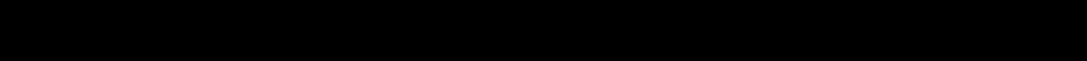

In [63]:
aa = df['date']     # Series
aa = df[['date']]   # DataFrame
type(aa)

df[['date','temp_max','weather']]

,date,temp_max,weather
0,2012-01-01,12.8,drizzle
1,2012-01-02,10.6,rain
2,2012-01-03,11.7,rain
3,2012-01-04,12.2,rain
4,2012-01-05,8.9,rain
...,...,...,...
1456,2015-12-27,4.4,rain
1457,2015-12-28,5.0,rain
1458,2015-12-29,7.2,fog
1459,2015-12-30,5.6,sun


# 3)按行获取数据
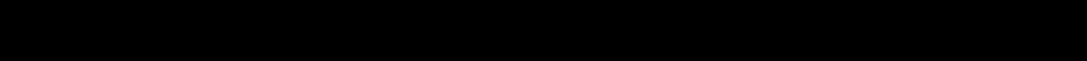

In [64]:
df
# 获取行标签为1的数据
df.loc[1]
# 获取行标签分别为1、10、100的数据
df.loc[[1,10,100]]

# 获取行位置为0的数据
df.iloc[0]
# 获取行位置为最后一位的数据
df.iloc[-1]

date             2015-12-31
precipitation           0.0
temp_max                5.6
temp_min               -2.1
wind                    3.5
weather                 sun
Name: 1460, dtype: object

# 4)获取指定行与列的数据

In [65]:
# 获取行标签为1，列标签为precipitation的数据
df.loc[1,'precipitation']
# 获取所有行，列标签为precipitation的数据
df.loc[:,'precipitation']
# 获取所有行，列位置为3，5，最后一位的数据 iloc隐式索引
df.iloc[:,[3,5,-1]]
# 获取前10行，列位置为2、3、4、5的数据
df.iloc[:10,2:6]
# 通过行列标签获取数据
df.loc[:9,'temp_max':'weather']

,temp_max,temp_min,wind,weather
0,12.8,5.0,4.7,drizzle
1,10.6,2.8,4.5,rain
2,11.7,7.2,2.3,rain
3,12.2,5.6,4.7,rain
4,8.9,2.8,6.1,rain
5,4.4,2.2,2.2,rain
6,7.2,2.8,2.3,rain
7,10.0,2.8,2.0,sun
8,9.4,5.0,3.4,rain
9,6.1,0.6,3.4,rain


# 分组聚合计算

## 1)将数据按月分组,并统计最大温度和最小温度的平均值
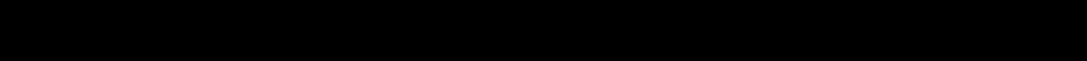
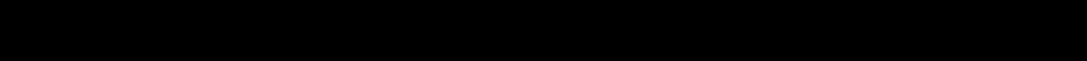

In [66]:
df['month'] = pd.to_datetime(df['date']).dt.to_period('M').astype(str)     # 多年份用to_period周期,最后转成字符串

# 指定分组字段进行分组    分组后得到的是一个DataFrameGroupBy对象,也可以理解为一个DataFrame
groupby_df = df.groupby('month')

# 指定要统计的字段
field_df = groupby_df[['temp_max','temp_min']]

# 调用聚合函数 进行统计
field_df.mean()

df.groupby('month')[['temp_max','temp_min']].mean()

,temp_max,temp_min
month,,
2012-01,7.054839,1.541935
2012-02,9.275862,3.203448
2012-03,9.554839,2.838710
2012-04,14.873333,5.993333
2012-05,17.661290,8.190323
2012-06,18.693333,10.480000
2012-07,22.906452,12.932258
2012-08,25.858065,14.009677
2012-09,22.880000,11.243333


## 分组频数计算
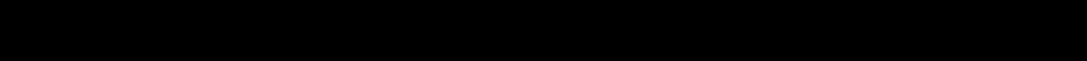

In [67]:
# 统计每个月不同天气状况的数量
df.groupby('month')['weather'].nunique()

month
2012-01    4
2012-02    4
2012-03    4
2012-04    4
2012-05    3
2012-06    3
2012-07    4
2012-08    3
2012-09    4
2012-10    3
2012-11    4
2012-12    4
2013-01    4
2013-02    3
2013-03    5
2013-04    4
2013-05    3
2013-06    2
2013-07    2
2013-08    3
2013-09    3
2013-10    3
2013-11    4
2013-12    3
2014-01    3
2014-02    3
2014-03    3
2014-04    2
2014-05    2
2014-06    2
2014-07    3
2014-08    3
2014-09    3
2014-10    3
2014-11    4
2014-12    3
2015-01    3
2015-02    3
2015-03    3
2015-04    3
2015-05    3
2015-06    4
2015-07    4
2015-08    4
2015-09    3
2015-10    4
2015-11    3
2015-12    3
Name: weather, dtype: int64

# 基本绘图

<Axes: xlabel='month'>

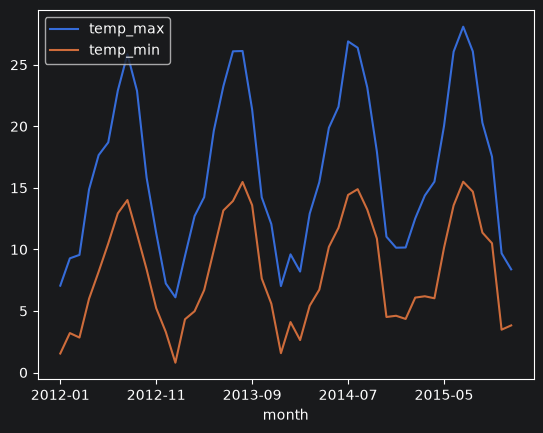

In [68]:
# 绘图
df.groupby('month')[['temp_max','temp_min']].mean().plot()

# 常用统计值

In [69]:
df.describe()

,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


# 常用排序方法

In [70]:
# 1)找到最高温度最大的30天
df.nlargest(30,'temp_max')

# 2)从最高温度最大的30天中找出最低温度最小的5天
df.nlargest(30,'temp_max').nsmallest(5,'temp_min')

# 3)找出每年的最高温度
df['year'] = pd.to_datetime(df['date']).dt.to_period('Y').astype(str)

df.groupby('year')['temp_max'].max()
df.sort_values(by=['year','temp_max'],ascending=[True,False,]).drop_duplicates(subset='year')   # 去重


,date,precipitation,temp_max,temp_min,wind,weather,month,year
228,2012-08-16,0.0,34.4,18.3,2.8,sun,2012-08,2012
546,2013-06-30,0.0,33.9,17.2,2.5,sun,2013-06,2013
953,2014-08-11,0.5,35.6,17.8,2.6,rain,2014-08,2014
1295,2015-07-19,0.0,35.0,17.2,3.3,sun,2015-07,2015
